In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations #

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load and explore data #

In [4]:
df = pd.read_csv('cardata.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (301, 9)

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Pric

# Check for missing values #

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


# Selling Price Distribution by Fuel Type #

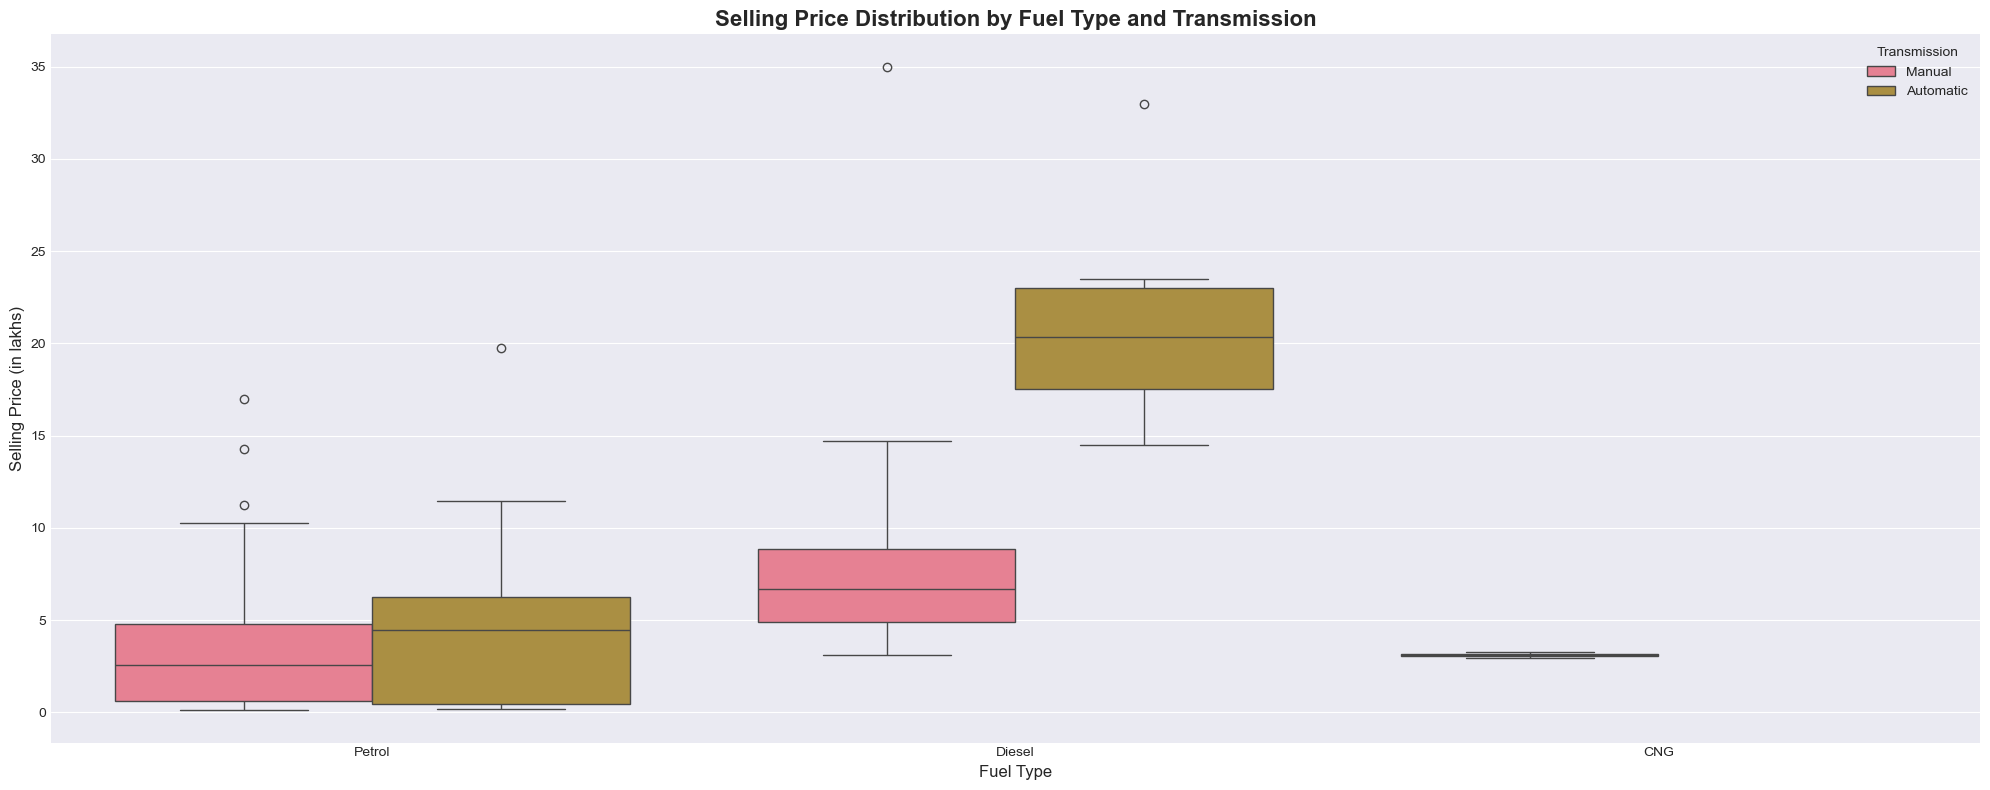

In [6]:
plt.figure(figsize=(20, 8))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', hue='Transmission')
plt.title('Selling Price Distribution by Fuel Type and Transmission', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Selling Price (in lakhs)', fontsize=12)
plt.legend(title='Transmission')
plt.tight_layout()
plt.show()

#  Car Age vs Selling Price (Bubble Chart) #

Newest car year: 2018
Reference year (newest + 1): 2019
Car ages range from 1 to 16 years


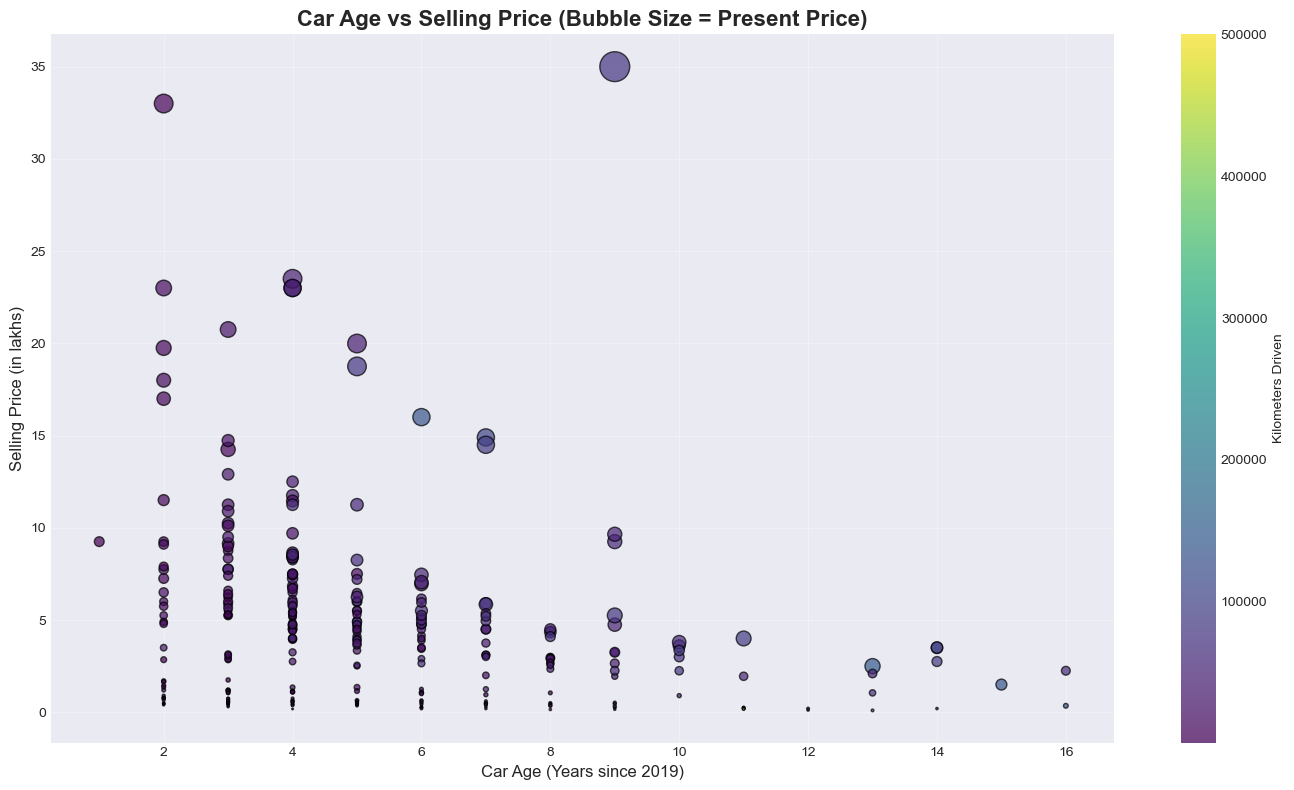

In [7]:
# Get the maximum year from the dataset and add 1
max_year = df['Year'].max()
reference_year = max_year + 1
df['Car_Age'] = reference_year - df['Year']

print(f"Newest car year: {max_year}")
print(f"Reference year (newest + 1): {reference_year}")
print(f"Car ages range from {df['Car_Age'].min()} to {df['Car_Age'].max()} years")

plt.figure(figsize=(14, 8))
scatter = plt.scatter(df['Car_Age'], df['Selling_Price'], 
                      s=df['Present_Price']*5,              # Bubble size based on Present Price
                      c=df['Kms_Driven'], 
                      cmap='viridis', 
                      alpha=0.7,
                      edgecolors='black')
plt.colorbar(scatter, label='Kilometers Driven')
plt.title(f'Car Age vs Selling Price (Bubble Size = Present Price)', fontsize=16, fontweight='bold')
plt.xlabel(f'Car Age (Years since {reference_year})', fontsize=12)
plt.ylabel('Selling Price (in lakhs)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  Heatmap of Correlations #

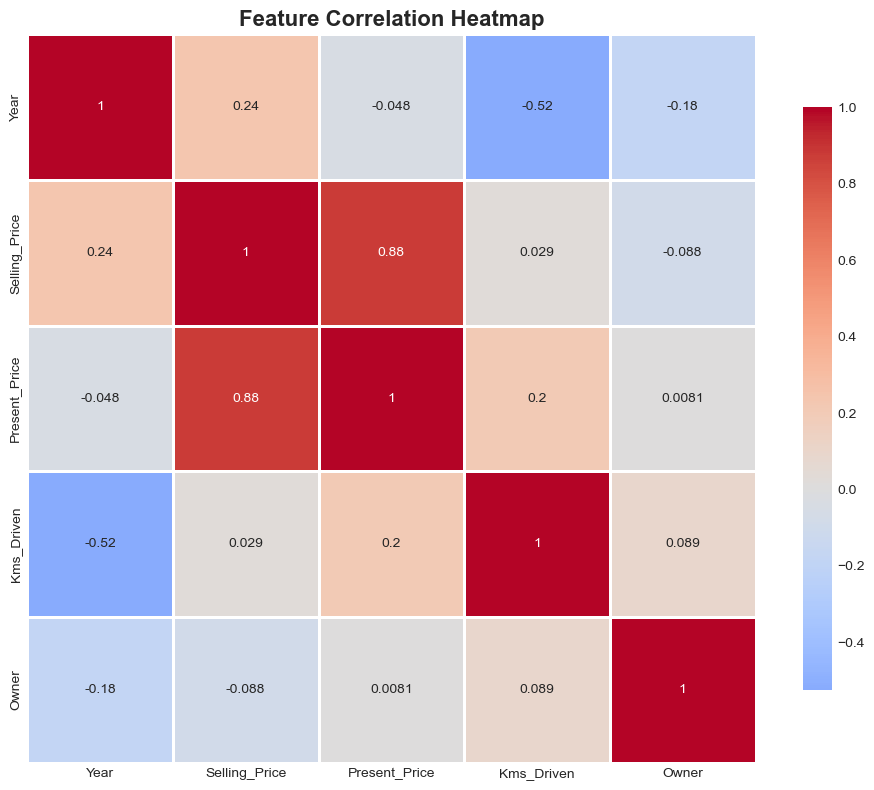

In [8]:
numeric_cols = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Selling Price Distribution by Seller Type #

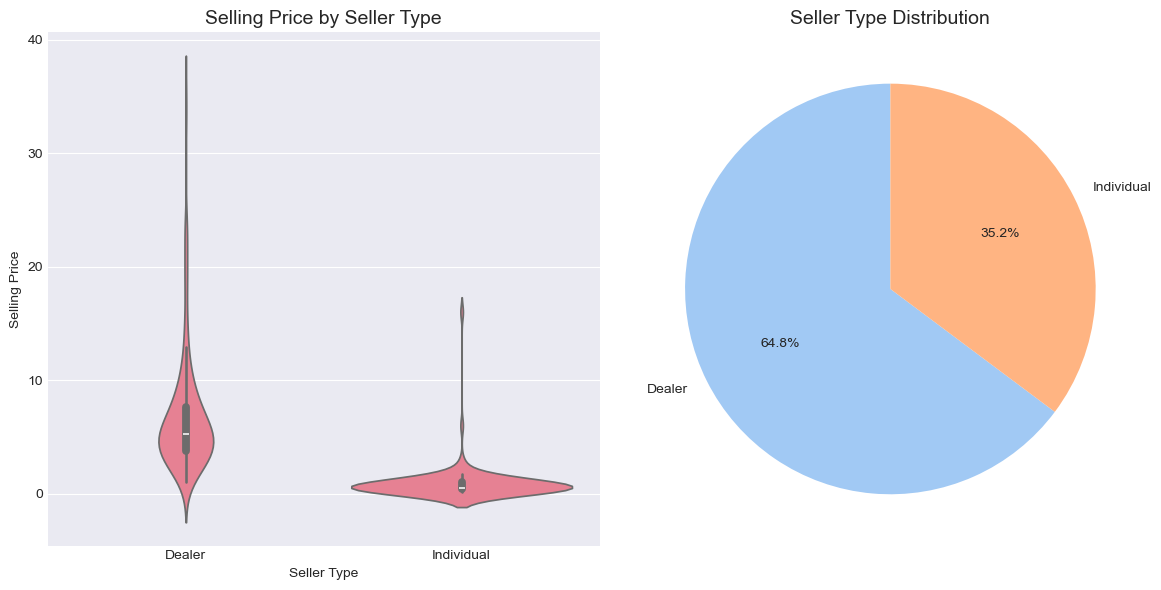

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x='Seller_Type', y='Selling_Price')
plt.title('Selling Price by Seller Type', fontsize=14)
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')

plt.subplot(1, 2, 2)
seller_counts = df['Seller_Type'].value_counts()
plt.pie(seller_counts.values, labels=seller_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Seller Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Top 20 Most Common Cars #

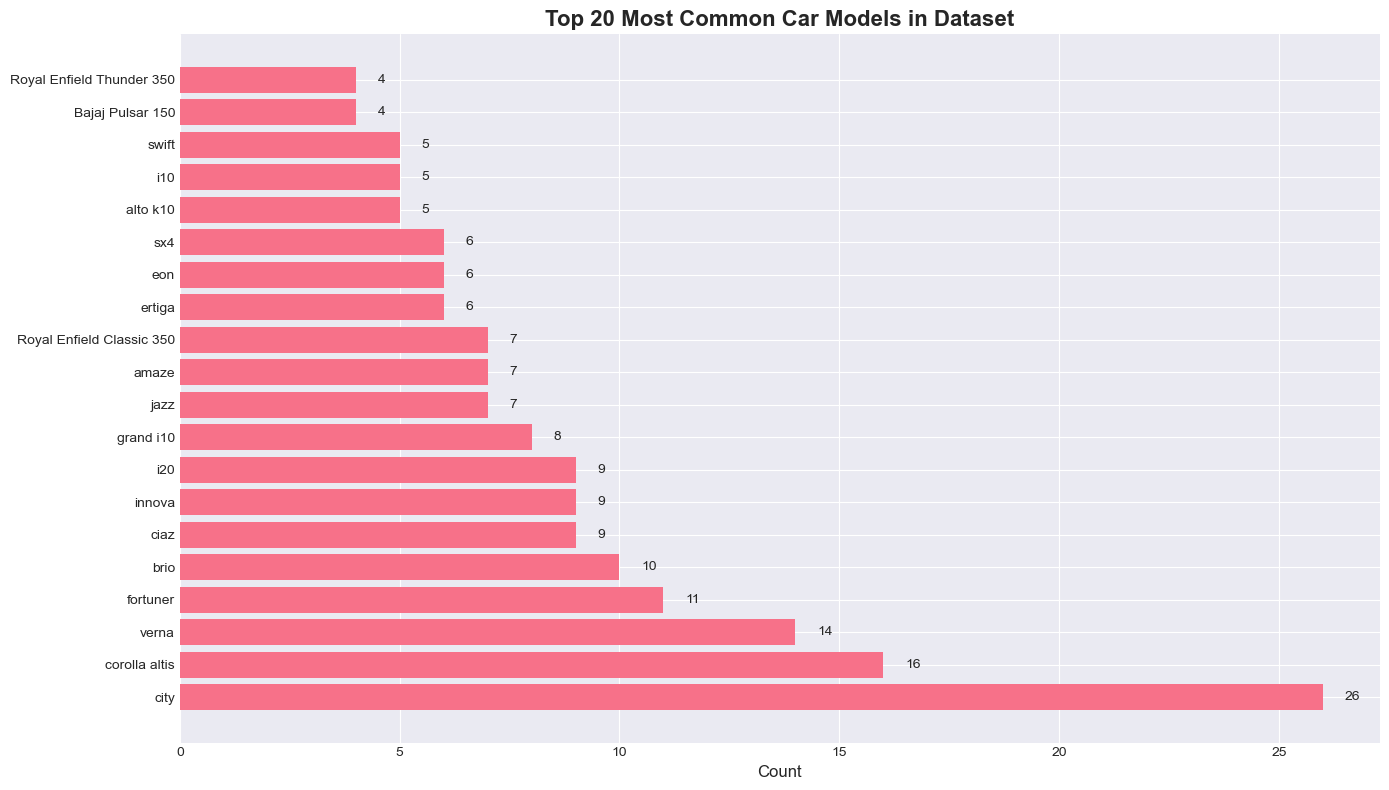

In [10]:
plt.figure(figsize=(14, 8))
top_cars = df['Car_Name'].value_counts().head(20)
bars = plt.barh(range(len(top_cars)), top_cars.values)
plt.yticks(range(len(top_cars)), top_cars.index)
plt.xlabel('Count', fontsize=12)
plt.title('Top 20 Most Common Car Models in Dataset', fontsize=16, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(bar.get_width()), va='center')
plt.tight_layout()
plt.show()

# KMS Driven Distribution by Transmission #

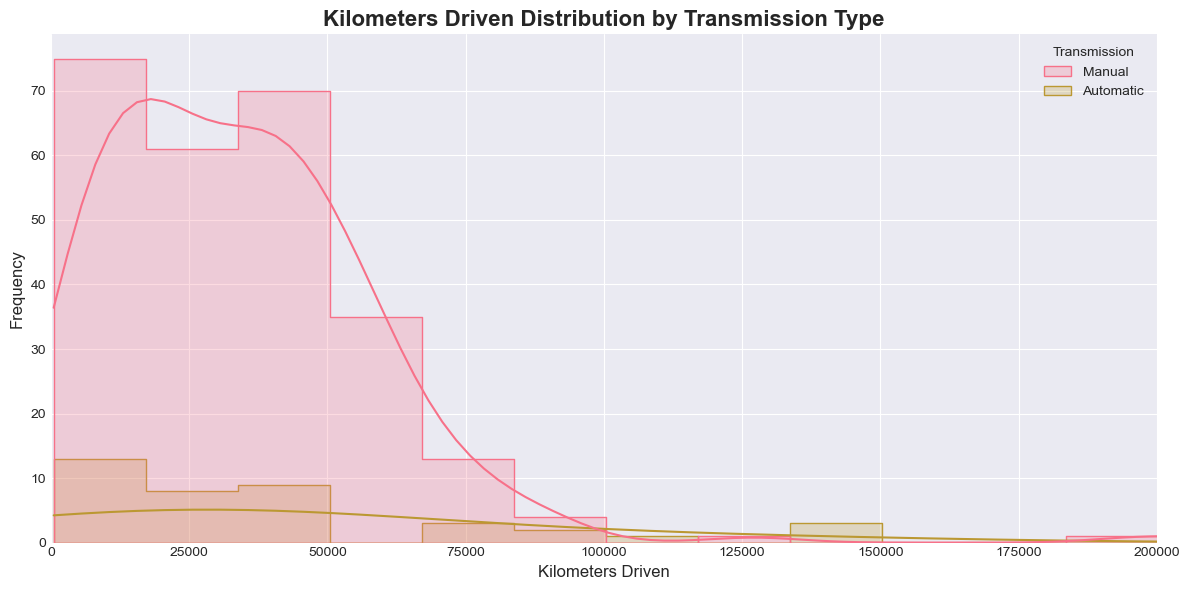

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Kms_Driven', hue='Transmission', 
             kde=True, element='step', bins=30)
plt.title('Kilometers Driven Distribution by Transmission Type', fontsize=16, fontweight='bold')
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 200000)                           # Limit x-axis for better visualization
plt.tight_layout()
plt.show()

# Price Trend Over Years #

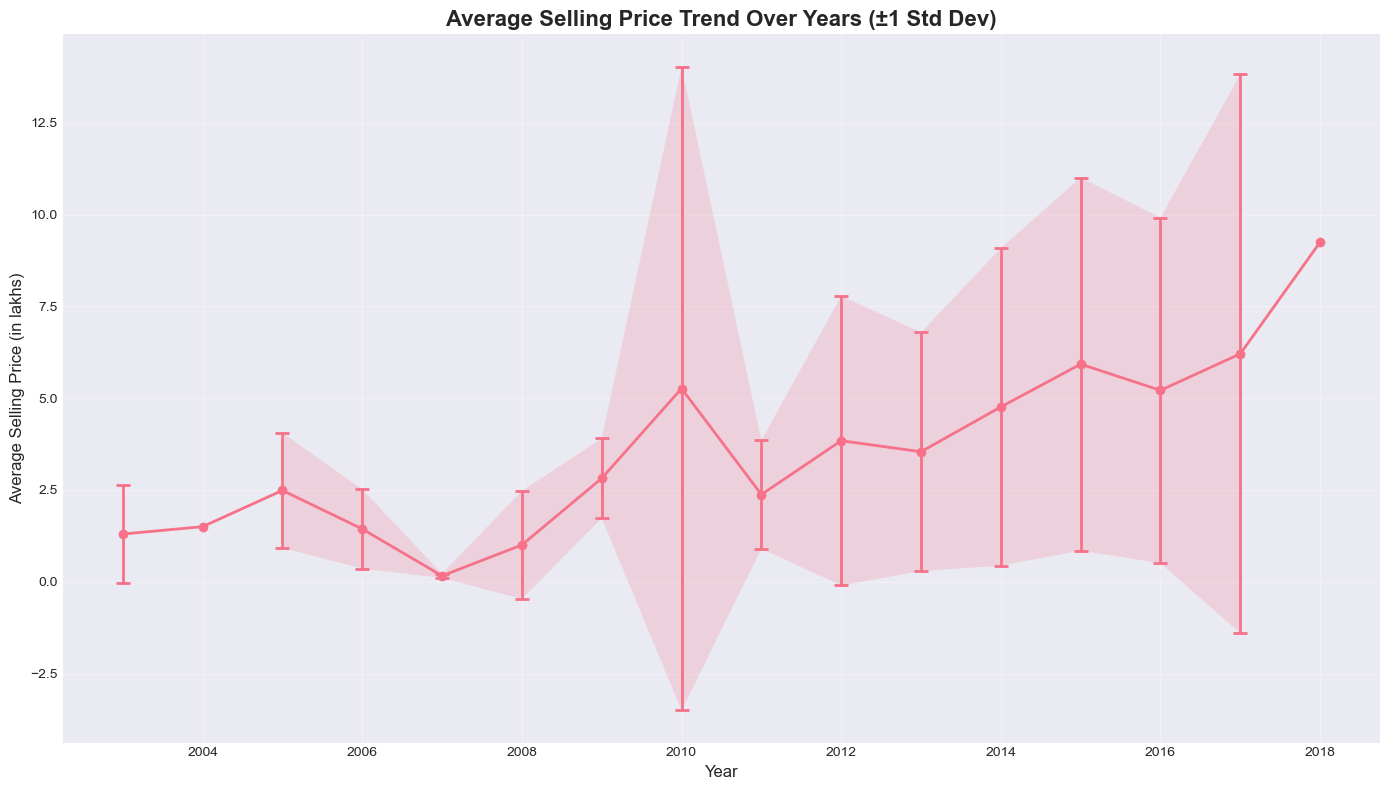

In [12]:
plt.figure(figsize=(14, 8))
yearly_stats = df.groupby('Year').agg({'Selling_Price': ['mean', 'std', 'count']}).reset_index()
yearly_stats.columns = ['Year', 'Mean_Price', 'Std_Price', 'Count']

plt.errorbar(yearly_stats['Year'], yearly_stats['Mean_Price'], 
             yerr=yearly_stats['Std_Price'], fmt='-o', 
             capsize=5, capthick=2, linewidth=2)
plt.fill_between(yearly_stats['Year'], 
                 yearly_stats['Mean_Price'] - yearly_stats['Std_Price'],
                 yearly_stats['Mean_Price'] + yearly_stats['Std_Price'],
                 alpha=0.2)
plt.title('Average Selling Price Trend Over Years (±1 Std Dev)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Selling Price (in lakhs)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Pairplot of Numerical Features #

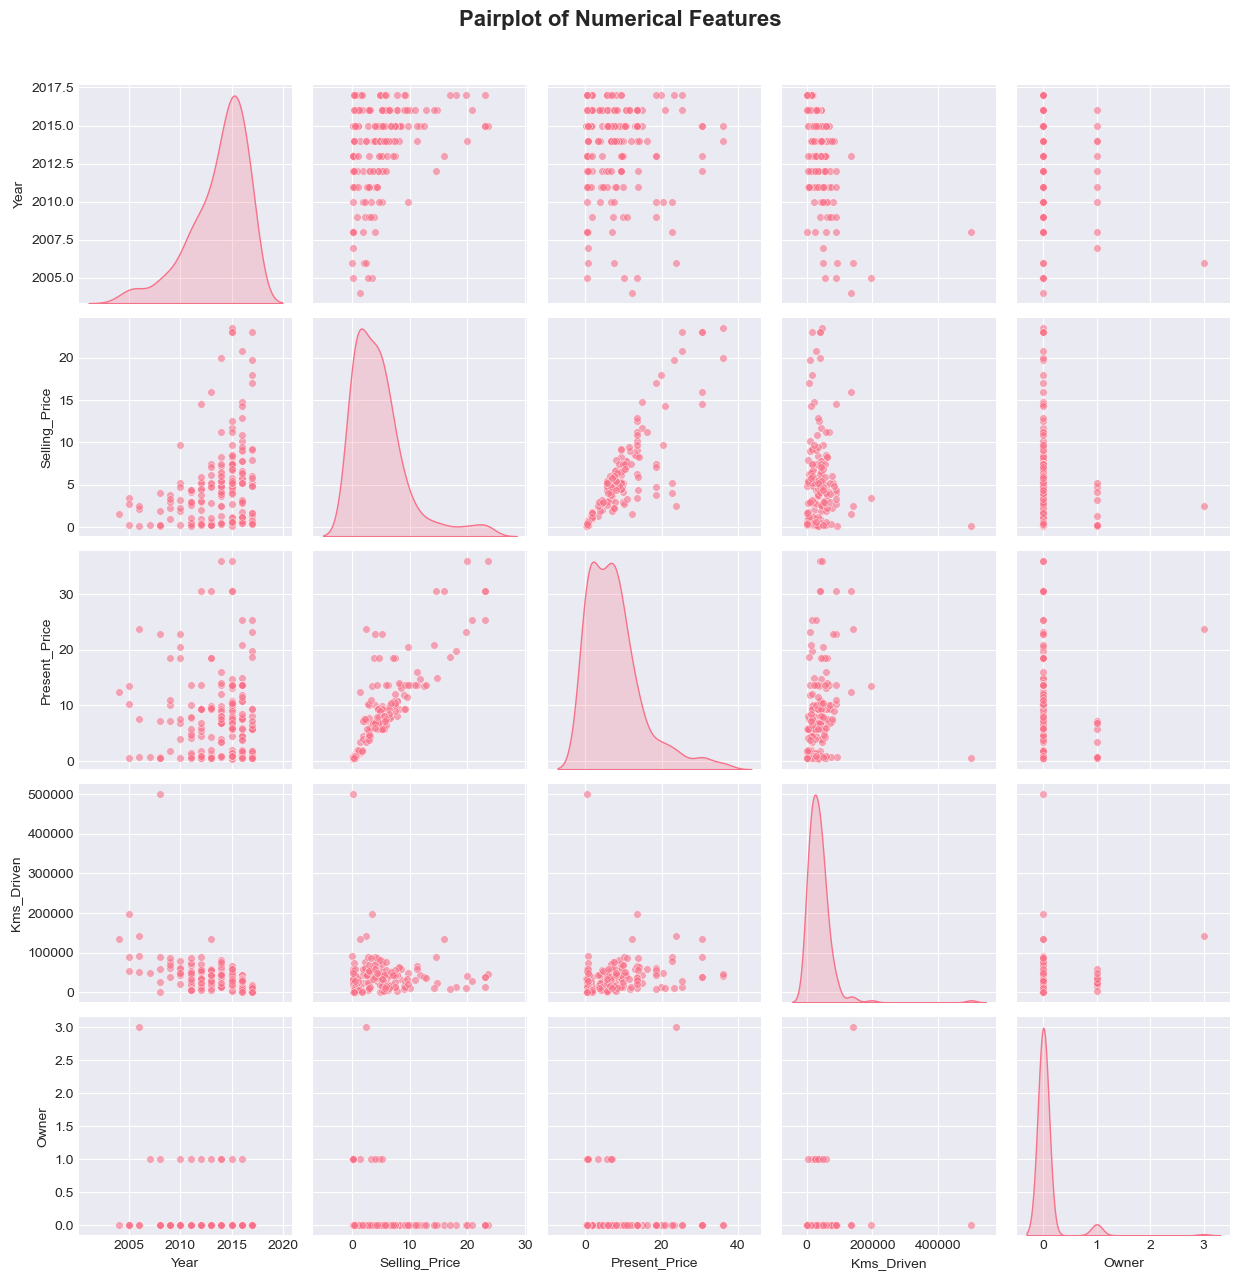

In [13]:
sample_df = df.sample(min(200, len(df)))                  # Sample for better performance
g = sns.pairplot(sample_df[numeric_cols], diag_kind='kde', 
                 plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Cell 12: Drop the temporary Car_Age column we created
df.drop('Car_Age', axis=1, inplace=True)
print("Temporary Car_Age column removed. Dataset restored to original state.")
print("Current columns:", df.columns.tolist())

Temporary Car_Age column removed. Dataset restored to original state.
Current columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


 # Sunburst/Rose Chart of Car Distribution #

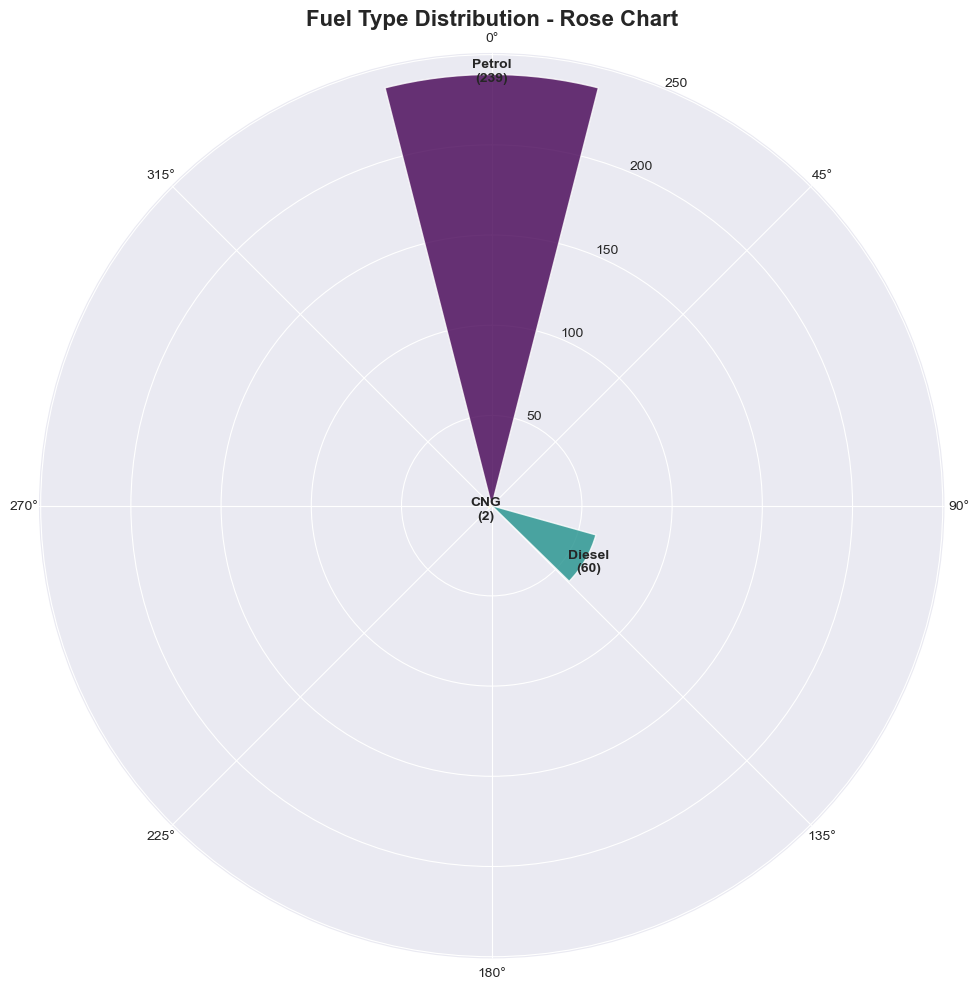

In [15]:
plt.figure(figsize=(12, 10))
# Prepare data for the rose chart
fuel_counts = df['Fuel_Type'].value_counts()
angles = np.linspace(0, 2*np.pi, len(fuel_counts), endpoint=False)
colors = plt.cm.viridis(np.linspace(0, 1, len(fuel_counts)))

# Create rose chart
ax = plt.subplot(111, projection='polar')
bars = ax.bar(angles, fuel_counts.values, width=0.5, 
              color=colors, alpha=0.8, edgecolor='white')

# Customize
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_title('Fuel Type Distribution - Rose Chart', fontsize=16, fontweight='bold', pad=20)

# Add labels
for angle, count, fuel in zip(angles, fuel_counts.values, fuel_counts.index):
    ax.text(angle, count+2, f'{fuel}\n({count})', 
            ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3D Scatter Plot of Price, KMS, and Year #

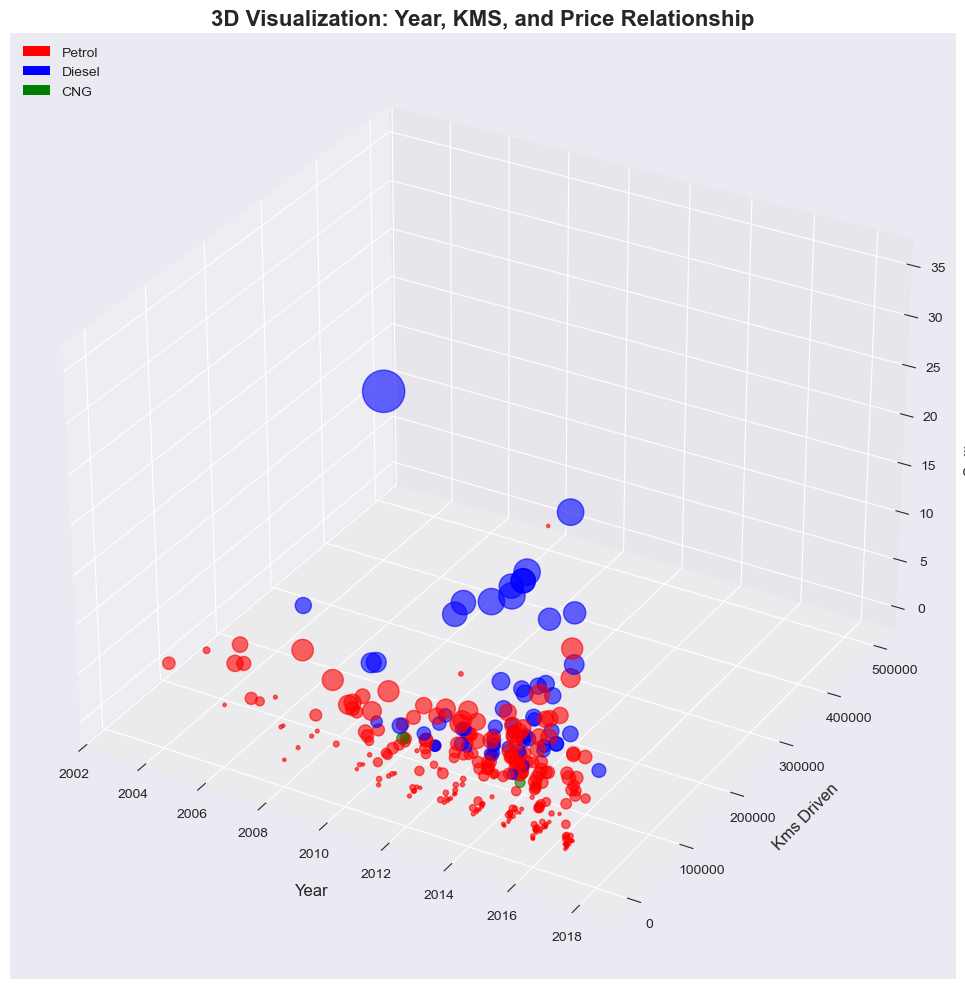

In [16]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create color mapping based on fuel type
fuel_colors = {'Petrol': 'red', 'Diesel': 'blue', 'CNG': 'green'}
colors = [fuel_colors[fuel] for fuel in df['Fuel_Type']]

# 3D Scatter plot
scatter = ax.scatter(df['Year'], df['Kms_Driven'], df['Selling_Price'], 
                    c=colors, s=df['Present_Price']*10, alpha=0.6)

ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Kms Driven', fontsize=12, labelpad=10)
ax.set_zlabel('Selling Price', fontsize=12, labelpad=10)
ax.set_title('3D Visualization: Year, KMS, and Price Relationship', fontsize=16, fontweight='bold')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Petrol'),
                  Patch(facecolor='blue', label='Diesel'),
                  Patch(facecolor='green', label='CNG')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Violin Plot with Swarm Overlay (for top cars) #

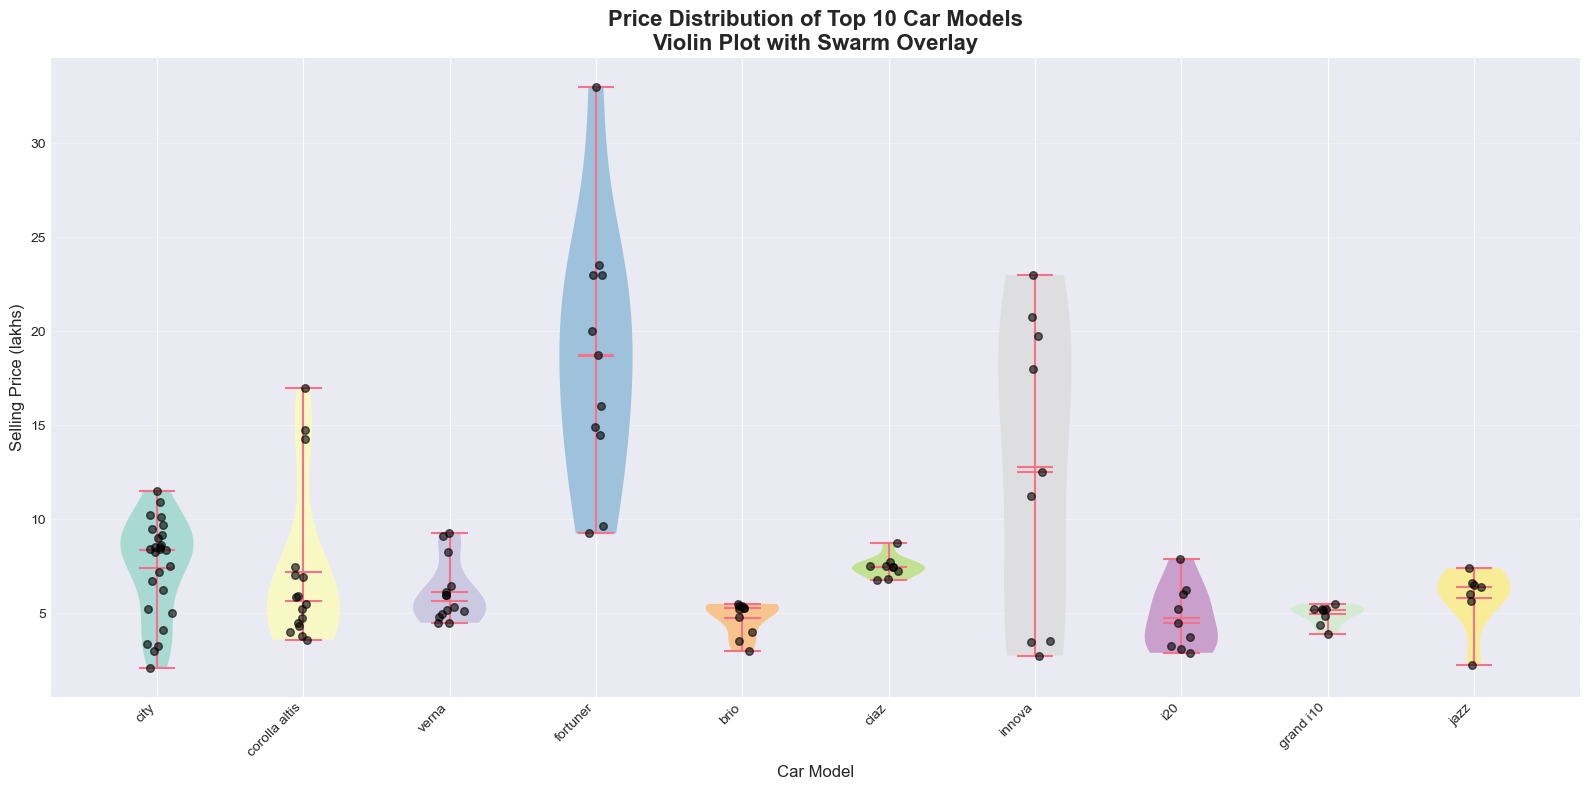

In [17]:
# Get top 10 cars by frequency
top_10_cars = df['Car_Name'].value_counts().head(10).index
df_top_cars = df[df['Car_Name'].isin(top_10_cars)]

plt.figure(figsize=(16, 8))

# Create violin plot
violin_parts = plt.violinplot([df_top_cars[df_top_cars['Car_Name'] == car]['Selling_Price'] 
                               for car in top_10_cars], 
                              positions=range(len(top_10_cars)), 
                              showmeans=True, showmedians=True)

# Color the violins
colors = plt.cm.Set3(np.linspace(0, 1, len(top_10_cars)))
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

# Add swarm plot overlay
for i, car in enumerate(top_10_cars):
    car_data = df_top_cars[df_top_cars['Car_Name'] == car]['Selling_Price']
    # Add jittered points
    y = car_data
    x = np.random.normal(i, 0.04, size=len(y))
    plt.scatter(x, y, alpha=0.6, s=30, color='black', zorder=3)

plt.xticks(range(len(top_10_cars)), top_10_cars, rotation=45, ha='right')
plt.xlabel('Car Model', fontsize=12)
plt.ylabel('Selling Price (lakhs)', fontsize=12)
plt.title('Price Distribution of Top 10 Car Models\nViolin Plot with Swarm Overlay', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Animated-style Step Plot of Price Distribution #

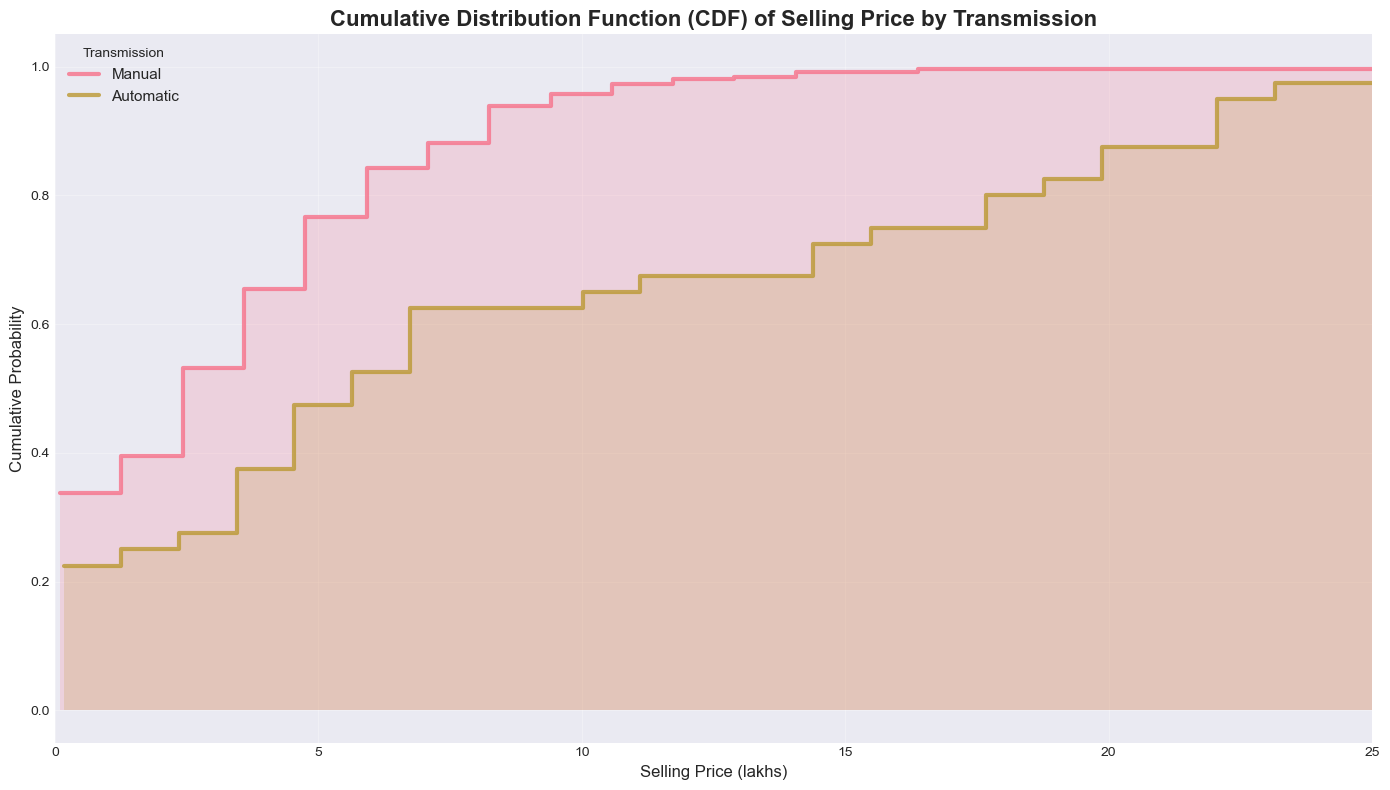

In [18]:
plt.figure(figsize=(14, 8))

# Create step plot for cumulative distribution
for transmission in df['Transmission'].unique():
    subset = df[df['Transmission'] == transmission]['Selling_Price']
    # Create histogram data
    counts, bins = np.histogram(subset, bins=30, density=True)
    cumulative = np.cumsum(counts) * np.diff(bins)[0]
    
    # Plot step
    plt.step(bins[:-1], cumulative, where='post', 
             linewidth=3, label=transmission, alpha=0.8)
    # Fill under the curve
    plt.fill_between(bins[:-1], 0, cumulative, step='post', alpha=0.2)

plt.xlabel('Selling Price (lakhs)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.title('Cumulative Distribution Function (CDF) of Selling Price by Transmission', 
          fontsize=16, fontweight='bold')
plt.legend(title='Transmission', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 25)            # Focus on main range
plt.tight_layout()
plt.show()

# Data Preprocessing - Feature Engineering #

In [19]:
# Create a copy for preprocessing
df_processed = df.copy()

# Calculate car age using max year + 1
max_year = df_processed['Year'].max()
reference_year = max_year + 1
df_processed['Car_Age'] = reference_year - df_processed['Year']
print(f"Reference year (max year + 1): {reference_year}")
print(f"Car age ranges from {df_processed['Car_Age'].min()} to {df_processed['Car_Age'].max()} years")

# Drop the original Year column since we now have Car_Age
df_processed.drop('Year', axis=1, inplace=True)

print("\nFeatures after engineering:")
print(df_processed.columns.tolist())
print(df_processed.head())

Reference year (max year + 1): 2019
Car age ranges from 1 to 16 years

Features after engineering:
['Car_Name', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
  Car_Name  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0     ritz           3.35           5.59       27000    Petrol      Dealer   
1      sx4           4.75           9.54       43000    Diesel      Dealer   
2     ciaz           7.25           9.85        6900    Petrol      Dealer   
3  wagon r           2.85           4.15        5200    Petrol      Dealer   
4    swift           4.60           6.87       42450    Diesel      Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0        5  
1       Manual      0        6  
2       Manual      0        2  
3       Manual      0        8  
4       Manual      0        5  


 # Encode Categorical Variables #

In [20]:
# Create a copy for encoding
df_encoded = df_processed.copy()

# Initialize LabelEncoders for each categorical column
le_fuel = LabelEncoder()
le_seller = LabelEncoder()
le_transmission = LabelEncoder()
le_car = LabelEncoder()           # For Car_Name

# Fit and transform categorical columns
df_encoded['Fuel_Type_Encoded'] = le_fuel.fit_transform(df_encoded['Fuel_Type'])
df_encoded['Seller_Type_Encoded'] = le_seller.fit_transform(df_encoded['Seller_Type'])
df_encoded['Transmission_Encoded'] = le_transmission.fit_transform(df_encoded['Transmission'])
df_encoded['Car_Name_Encoded'] = le_car.fit_transform(df_encoded['Car_Name'])

# Drop original categorical columns
df_encoded.drop(['Fuel_Type', 'Seller_Type', 'Transmission', 'Car_Name'], axis=1, inplace=True)

print("Encoded categorical variables:")
print(df_encoded.head())
print(f"\nEncoded classes:")
print(f"Fuel Types: {dict(zip(le_fuel.classes_, le_fuel.transform(le_fuel.classes_)))}")
print(f"Seller Types: {dict(zip(le_seller.classes_, le_seller.transform(le_seller.classes_)))}")
print(f"Transmission: {dict(zip(le_transmission.classes_, le_transmission.transform(le_transmission.classes_)))}")

Encoded categorical variables:
   Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  \
0           3.35           5.59       27000      0        5   
1           4.75           9.54       43000      0        6   
2           7.25           9.85        6900      0        2   
3           2.85           4.15        5200      0        8   
4           4.60           6.87       42450      0        5   

   Fuel_Type_Encoded  Seller_Type_Encoded  Transmission_Encoded  \
0                  2                    0                     1   
1                  1                    0                     1   
2                  2                    0                     1   
3                  2                    0                     1   
4                  1                    0                     1   

   Car_Name_Encoded  
0                90  
1                93  
2                68  
3                96  
4                92  

Encoded classes:
Fuel Types: {'CNG': 0, 'Diesel': 1, '

# Separate Features and Target #

In [21]:
# Define features (X) and target (y)
#'Selling_Price' is our target variable
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used for training:")
print(X.columns.tolist())
print("\nFirst 5 rows of features:")
print(X.head())

Features shape: (301, 8)
Target shape: (301,)

Features used for training:
['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Encoded', 'Seller_Type_Encoded', 'Transmission_Encoded', 'Car_Name_Encoded']

First 5 rows of features:
   Present_Price  Kms_Driven  Owner  Car_Age  Fuel_Type_Encoded  \
0           5.59       27000      0        5                  2   
1           9.54       43000      0        6                  1   
2           9.85        6900      0        2                  2   
3           4.15        5200      0        8                  2   
4           6.87       42450      0        5                  1   

   Seller_Type_Encoded  Transmission_Encoded  Car_Name_Encoded  
0                    0                     1                90  
1                    0                     1                93  
2                    0                     1                68  
3                    0                     1                96  
4                    0        

# Normalize the features BEFORE splitting #

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print("Features after normalization:")
print(f"Mean of each feature (should be ~0):\n{X_normalized.mean().round(2)}")
print(f"\nStandard deviation of each feature (should be ~1):\n{X_normalized.std().round(2)}")
print(f"\nNormalized data shape: {X_normalized.shape}")
print("\nFirst 5 rows of normalized features:")
print(X_normalized.head())

Features after normalization:
Mean of each feature (should be ~0):
Present_Price          -0.0
Kms_Driven              0.0
Owner                   0.0
Car_Age                 0.0
Fuel_Type_Encoded       0.0
Seller_Type_Encoded     0.0
Transmission_Encoded   -0.0
Car_Name_Encoded        0.0
dtype: float64

Standard deviation of each feature (should be ~1):
Present_Price           1.0
Kms_Driven              1.0
Owner                   1.0
Car_Age                 1.0
Fuel_Type_Encoded       1.0
Seller_Type_Encoded     1.0
Transmission_Encoded    1.0
Car_Name_Encoded        1.0
dtype: float64

Normalized data shape: (301, 8)

First 5 rows of normalized features:
   Present_Price  Kms_Driven     Owner   Car_Age  Fuel_Type_Encoded  \
0      -0.236215   -0.256224 -0.174501 -0.128897           0.500183   
1       0.221505    0.155911 -0.174501  0.217514          -1.852241   
2       0.257427   -0.773969 -0.174501 -1.168129           0.500183   
3      -0.403079   -0.817758 -0.174501  0.910335

# Split the normalized data into train and test sets #

In [23]:
# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\nTraining samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Training set size: (240, 8)
Testing set size: (61, 8)

Training samples: 240 (79.7%)
Testing samples: 61 (20.3%)


# Verify normalization is preserved after split #

Normalization verification (should be similar means/std across splits):

Training set statistics:
Mean of all features: 0.0062
Std of all features: 1.0252
Individual feature means:
Present_Price          -0.01
Kms_Driven              0.01
Owner                   0.03
Car_Age                -0.01
Fuel_Type_Encoded       0.02
Seller_Type_Encoded     0.01
Transmission_Encoded    0.02
Car_Name_Encoded       -0.02
dtype: float64
Individual feature stds:
Present_Price           1.04
Kms_Driven              1.08
Owner                   1.09
Car_Age                 1.00
Fuel_Type_Encoded       1.00
Seller_Type_Encoded     1.01
Transmission_Encoded    0.98
Car_Name_Encoded        1.01
dtype: float64

Testing set statistics:
Mean of all features: -0.0242
Std of all features: 0.8823
Individual feature means:
Present_Price           0.05
Kms_Driven             -0.06
Owner                  -0.11
Car_Age                 0.06
Fuel_Type_Encoded      -0.08
Seller_Type_Encoded    -0.05
Transmission_Enco

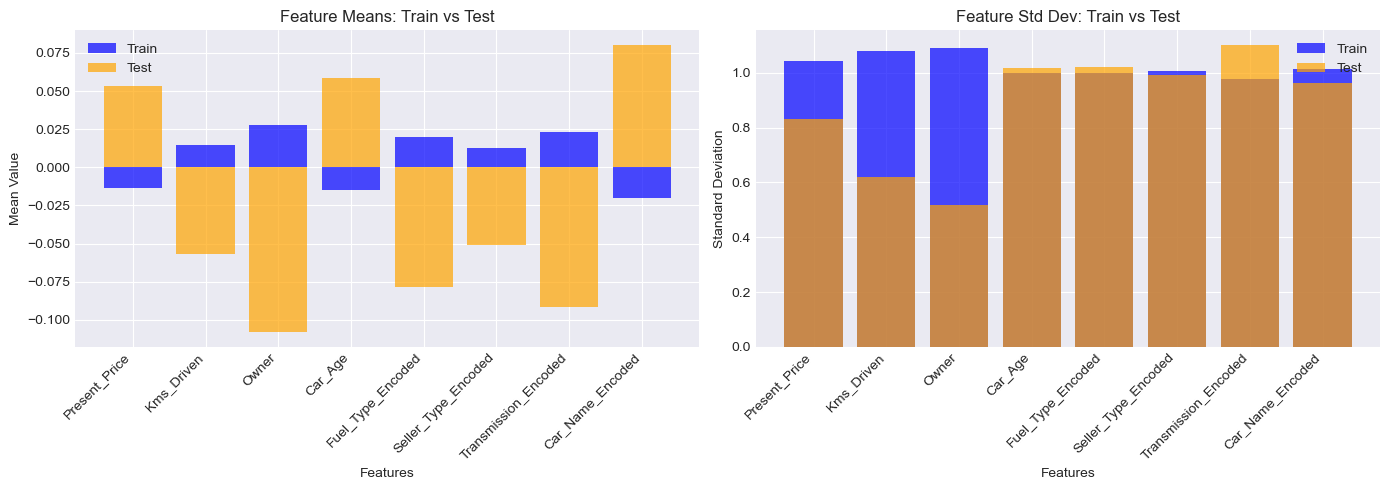

In [24]:
print("Normalization verification (should be similar means/std across splits):")
print("\n" + "="*50)
print("Training set statistics:")
print(f"Mean of all features: {X_train.mean().mean():.4f}")
print(f"Std of all features: {X_train.std().mean():.4f}")
print(f"Individual feature means:\n{X_train.mean().round(2)}")
print(f"Individual feature stds:\n{X_train.std().round(2)}")

print("\n" + "="*50)
print("Testing set statistics:")
print(f"Mean of all features: {X_test.mean().mean():.4f}")
print(f"Std of all features: {X_test.std().mean():.4f}")
print(f"Individual feature means:\n{X_test.mean().round(2)}")
print(f"Individual feature stds:\n{X_test.std().round(2)}")

# Quick verification plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot means comparison
axes[0].bar(range(len(X_train.columns)), X_train.mean(), alpha=0.7, label='Train', color='blue')
axes[0].bar(range(len(X_test.columns)), X_test.mean(), alpha=0.7, label='Test', color='orange')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Mean Value')
axes[0].set_title('Feature Means: Train vs Test')
axes[0].legend()
axes[0].set_xticks(range(len(X_train.columns)))
axes[0].set_xticklabels(X_train.columns, rotation=45, ha='right')

# Plot std comparison
axes[1].bar(range(len(X_train.columns)), X_train.std(), alpha=0.7, label='Train', color='blue')
axes[1].bar(range(len(X_test.columns)), X_test.std(), alpha=0.7, label='Test', color='orange')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Feature Std Dev: Train vs Test')
axes[1].legend()
axes[1].set_xticks(range(len(X_train.columns)))
axes[1].set_xticklabels(X_train.columns, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Training The Linear Regression model #

In [25]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Evaluate the model
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear Regression Results:")
print("=" * 50)
print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.4f}")

Linear Regression Results:
Training R² Score: 0.8841
Testing R² Score: 0.8466
Training RMSE: 1.7507
Testing RMSE: 1.8801

Model Coefficients:
Present_Price: 3.8018
Kms_Driven: -0.2182
Owner: -0.2251
Car_Age: -1.0449
Fuel_Type_Encoded: -0.5694
Seller_Type_Encoded: -0.6246
Transmission_Encoded: -0.5565
Car_Name_Encoded: -0.0844


# Train a Linear Regression model #

In [26]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

# Evaluate the model
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear Regression Results:")
print("=" * 50)
print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef:.4f}")

Linear Regression Results:
Training R² Score: 0.8841
Testing R² Score: 0.8466
Training RMSE: 1.7507
Testing RMSE: 1.8801

Model Coefficients:
Present_Price: 3.8018
Kms_Driven: -0.2182
Owner: -0.2251
Car_Age: -1.0449
Fuel_Type_Encoded: -0.5694
Seller_Type_Encoded: -0.6246
Transmission_Encoded: -0.5565
Car_Name_Encoded: -0.0844


# Cross-validation for more robust evaluation #

In [27]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(lr_model, X_normalized, y, cv=5, scoring='r2')

print("5-Fold Cross-Validation Results:")
print("=" * 40)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")

5-Fold Cross-Validation Results:
CV Scores: [   0.83208066    0.77502966 -102.79696228    0.57409757    0.83866341]
Mean CV Score: -19.9554
Std CV Score: 41.4209


# Trying Polynomial Features for potentially better results #

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Try different polynomial degrees
degrees = [1, 2, 3]
results = {}

for degree in degrees:
    # Create polynomial regression pipeline
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    
    # Train and evaluate
    poly_model.fit(X_train, y_train)
    y_pred = poly_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[degree] = {'R2': r2, 'RMSE': rmse}
    
    print(f"\nPolynomial Degree {degree}:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")

# Find best degree
best_degree = max(results, key=lambda x: results[x]['R2'])
print(f"\n{'='*40}")
print(f"Best Polynomial Degree: {best_degree}")
print(f"Best R² Score: {results[best_degree]['R2']:.4f}")


Polynomial Degree 1:
R² Score: 0.8466
RMSE: 1.8801

Polynomial Degree 2:
R² Score: 0.9750
RMSE: 0.7593

Polynomial Degree 3:
R² Score: -182404253051173312.0000
RMSE: 2049826477.5392

Best Polynomial Degree: 2
Best R² Score: 0.9750


# Visualize Model Performance #

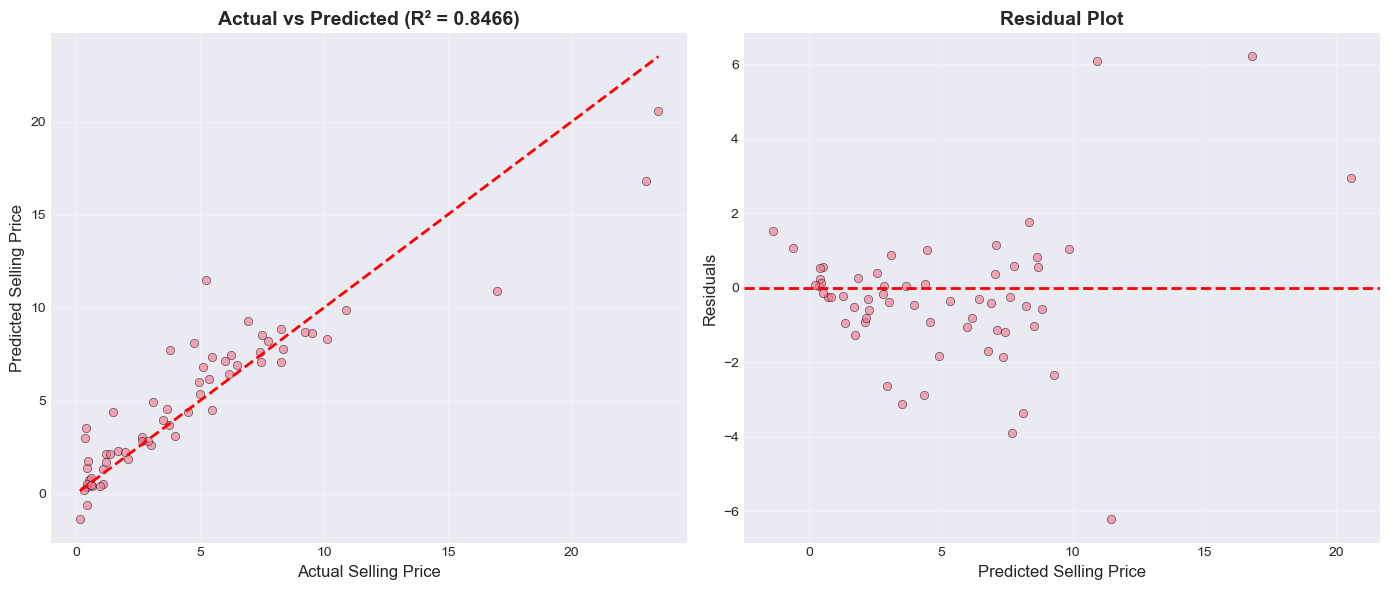

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Selling Price', fontsize=12)
axes[0].set_ylabel('Predicted Selling Price', fontsize=12)
axes[0].set_title(f'Actual vs Predicted (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Selling Price', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance Analysis #

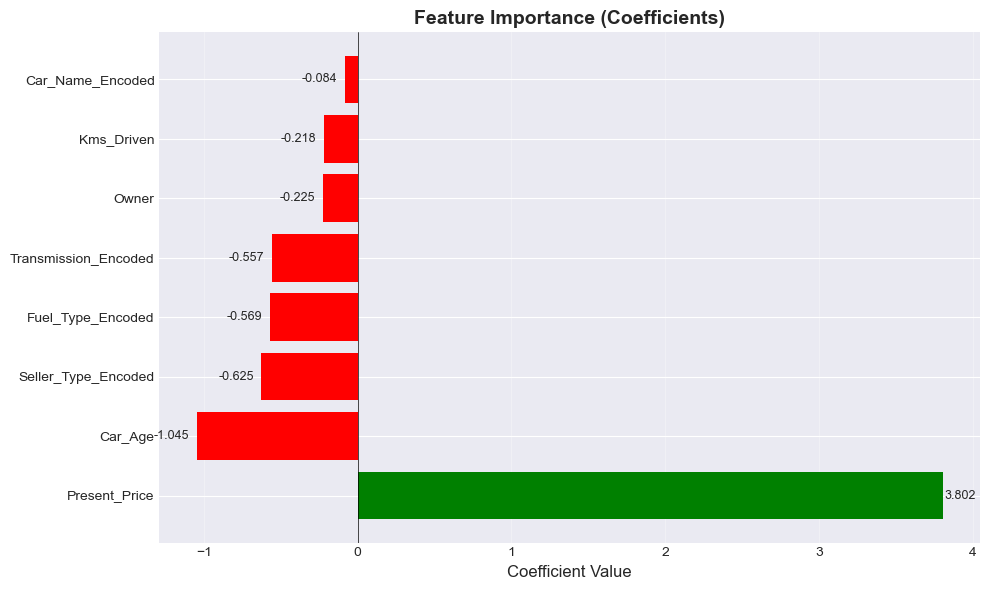


Top 5 Most Important Features:
                Feature  Coefficient
0         Present_Price     3.801827
3               Car_Age    -1.044920
5   Seller_Type_Encoded    -0.624569
4     Fuel_Type_Encoded    -0.569401
6  Transmission_Encoded    -0.556519


In [30]:
# Get feature importance from coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
bars = plt.barh(range(len(feature_importance)), feature_importance['Coefficient'], color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Importance (Coefficients)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (0.01 if width > 0 else -0.05), bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left' if width > 0 else 'right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance[['Feature', 'Coefficient']].head())